In [ ]:
!pip install beir
!pip install rank_bm25
!pip install sentence-transformers
!pip install faiss-cpu
!pip install pytrec_eval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 91.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pytrec_eval: filename=pytrec_eval-0.5-cp312-cp312-linux_x86_64.whl size=309354 sha256=e865511589f58955cf9fb09a71afb61096d5199911d8daae7db99ca944e9d29c
  Stored in directory: /root/.cache/pip/wheels/c6/4a/9e/e17f9ea004e1c221bd0ff384732285211c4917b790d598ea51
Successfully built pytrec_eval


In [ ]:
from beir import util
from beir.datasets.data_loader import GenericDataLoader

# Download FiQA dataset (financial domain - closest to regulatory)
dataset = "fiqa"
url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{dataset}.zip"
data_path = util.download_and_unzip(url, "datasets")

# Load corpus, queries, and relevance judgments
corpus, queries, qrels = GenericDataLoader(data_folder=data_path).load(split="test")

print(f"Documents: {len(corpus)}")   # ~57,000 documents
print(f"Queries: {len(queries)}")     # ~648 queries
print(f"Relevance pairs: {len(qrels)}")

/usr/local/lib/python3.12/dist-packages/beir/util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


datasets/fiqa.zip:   0%|          | 0.00/17.1M [00:00<?, ?iB/s]

  0%|          | 0/57638 [00:00<?, ?it/s]

Documents: 57638
Queries: 648
Relevance pairs: 648


BM25


In [ ]:
# Step 1: Install correct libraries
!pip install rank_bm25 beir pytrec_eval -q

# Step 2: Imports
from beir import util
from beir.datasets.data_loader import GenericDataLoader
from rank_bm25 import BM25Okapi
import numpy as np
import json
import os

# Step 3: Download and load FiQA dataset
dataset = "fiqa"
url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{dataset}.zip"
data_path = util.download_and_unzip(url, "datasets")

corpus, queries, qrels = GenericDataLoader(data_folder=data_path).load(split="test")

print(f"Documents loaded: {len(corpus)}")
print(f" Queries loaded: {len(queries)}")
print(f" Relevance judgments: {len(qrels)}")

  0%|          | 0/57638 [00:00<?, ?it/s]

Documents loaded: 57638
 Queries loaded: 648
 Relevance judgments: 648


In [ ]:
# Prepare corpus for BM25
print("Preparing BM25 index...")

# Get ordered list of doc IDs and tokenized texts
corpus_ids = list(corpus.keys())
tokenized_corpus = [
    (corpus[doc_id]['title'] + " " + corpus[doc_id]['text']).lower().split()
    for doc_id in corpus_ids
]

# Build BM25 index
bm25 = BM25Okapi(tokenized_corpus)
print(f"✅ BM25 index built over {len(corpus_ids)} documents")

# Retrieve top-100 docs for each query
print("Running BM25 retrieval...")
results_bm25 = {}

for query_id, query_text in queries.items():
    tokenized_query = query_text.lower().split()
    scores = bm25.get_scores(tokenized_query)

    # Get top 100 document indices
    top_indices = np.argsort(scores)[::-1][:100]

    results_bm25[query_id] = {
        corpus_ids[i]: float(scores[i])
        for i in top_indices
        if scores[i] > 0
    }

print(f"✅ BM25 retrieval done for {len(results_bm25)} queries")

Preparing BM25 index...
✅ BM25 index built over 57638 documents
Running BM25 retrieval...
✅ BM25 retrieval done for 648 queries


In [ ]:
import pytrec_eval

def evaluate_results(qrels, results, k_values=[1, 3, 5, 10, 100]):
    """Evaluate retrieval results using pytrec_eval"""

    # Build evaluator
    measures = {f"ndcg_cut_{k}" for k in k_values} | \
               {f"map_cut_{k}" for k in k_values} | \
               {f"recall_{k}" for k in k_values}

    evaluator = pytrec_eval.RelevanceEvaluator(qrels, measures)
    scores = evaluator.evaluate(results)

    # Average across queries
    avg_scores = {}
    for measure in measures:
        avg_scores[measure] = np.mean([
            scores[q][measure] for q in scores if measure in scores[q]
        ])

    return avg_scores

# Evaluate BM25
bm25_scores = evaluate_results(qrels, results_bm25)

print("\n=== BM25 Results ===")
print(f"NDCG@10  : {bm25_scores['ndcg_cut_10']:.4f}")
print(f"MAP@10   : {bm25_scores['map_cut_10']:.4f}")
print(f"Recall@100: {bm25_scores['recall_100']:.4f}")


=== BM25 Results ===
NDCG@10  : 0.1591
MAP@10   : 0.1163
Recall@100: 0.3590


In [ ]:
import json
import numpy as np

# Save BM25 retrieval results
with open('results_bm25.json', 'w') as f:
    json.dump(results_bm25, f)

# Save BM25 scores
bm25_final = {
    'ndcg@10': bm25_scores['ndcg_cut_10'],
    'map@10': bm25_scores['map_cut_10'],
    'recall@100': bm25_scores['recall_100']
}
with open('scores_bm25.json', 'w') as f:
    json.dump(bm25_final, f)

print("BM25 results saved. Safe to proceed.")

BM25 results saved. Safe to proceed.


In [ ]:
# Reload dataset (run this first before anything else)
from beir import util
from beir.datasets.data_loader import GenericDataLoader

# FiQA is already downloaded, just reload it
data_path = "datasets/fiqa"

corpus, queries, qrels = GenericDataLoader(data_folder=data_path).load(split="test")

print(f"✅ Corpus: {len(corpus)} documents")
print(f"✅ Queries: {len(queries)} queries")
print(f"✅ Qrels: {len(qrels)} relevance judgments")

  0%|          | 0/57638 [00:00<?, ?it/s]

✅ Corpus: 57638 documents
✅ Queries: 648 queries
✅ Qrels: 648 relevance judgments


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Create a folder for your project
import os
os.makedirs('/content/drive/MyDrive/IR_Research', exist_ok=True)
print("✅ Google Drive connected. Files will persist here.")

Mounted at /content/drive
✅ Google Drive connected. Files will persist here.


In [ ]:
!pip install beir rank_bm25 pytrec_eval sentence-transformers faiss-cpu -q

from beir import util
from beir.datasets.data_loader import GenericDataLoader
from rank_bm25 import BM25Okapi
import numpy as np
import json
import os

# Download/reload FiQA
data_path = "datasets/fiqa"
if not os.path.exists(data_path):
    url = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip"
    data_path = util.download_and_unzip(url, "datasets")

corpus, queries, qrels = GenericDataLoader(data_folder=data_path).load(split="test")
print(f"✅ Corpus: {len(corpus)} | Queries: {len(queries)} | Qrels: {len(qrels)}")

  0%|          | 0/57638 [00:00<?, ?it/s]

✅ Corpus: 57638 | Queries: 648 | Qrels: 648


In [ ]:
import pytrec_eval

def evaluate_results(qrels, results, k_values=[1, 3, 5, 10, 100]):
    measures = {f"ndcg_cut_{k}" for k in k_values} | \
               {f"map_cut_{k}" for k in k_values} | \
               {f"recall_{k}" for k in k_values}
    evaluator = pytrec_eval.RelevanceEvaluator(qrels, measures)
    scores = evaluator.evaluate(results)
    avg_scores = {}
    for measure in measures:
        avg_scores[measure] = np.mean([
            scores[q][measure] for q in scores if measure in scores[q]
        ])
    return avg_scores

bm25_scores = evaluate_results(qrels, results_bm25)

print("\n=== BM25 Results ===")
print(f"NDCG@10   : {bm25_scores['ndcg_cut_10']:.4f}")
print(f"MAP@10    : {bm25_scores['map_cut_10']:.4f}")
print(f"Recall@100: {bm25_scores['recall_100']:.4f}")

# Save scores too
with open('/content/drive/MyDrive/IR_Research/scores_bm25.json', 'w') as f:
    json.dump({k: float(v) for k, v in bm25_scores.items()}, f)


=== BM25 Results ===
NDCG@10   : 0.1591
MAP@10    : 0.1163
Recall@100: 0.3590


In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

# Install libraries
!pip install beir rank_bm25 pytrec_eval sentence-transformers faiss-cpu -q

# Reload corpus
from beir import util
from beir.datasets.data_loader import GenericDataLoader
import numpy as np
import json
import os

data_path = "datasets/fiqa"
if not os.path.exists(data_path):
    url = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip"
    data_path = util.download_and_unzip(url, "datasets")

corpus, queries, qrels = GenericDataLoader(data_folder=data_path).load(split="test")
print(f"✅ Corpus: {len(corpus)} | Queries: {len(queries)}")

# Reload BM25 results from Drive
with open('/content/drive/MyDrive/IR_Research/results_bm25.json', 'r') as f:
    results_bm25 = json.load(f)

with open('/content/drive/MyDrive/IR_Research/corpus_ids.json', 'r') as f:
    corpus_ids = json.load(f)

print("✅ BM25 results reloaded from Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


  0%|          | 0/57638 [00:00<?, ?it/s]

✅ Corpus: 57638 | Queries: 648
✅ BM25 results reloaded from Drive


In [ ]:
# Build BM25
corpus_ids = list(corpus.keys())
tokenized_corpus = [
    (corpus[doc_id]['title'] + " " + corpus[doc_id]['text']).lower().split()
    for doc_id in corpus_ids
]

bm25 = BM25Okapi(tokenized_corpus)
print("✅ BM25 index built")

# Retrieve
results_bm25 = {}
for query_id, query_text in queries.items():
    tokenized_query = query_text.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:100]
    results_bm25[query_id] = {
        corpus_ids[i]: float(scores[i])
        for i in top_indices if scores[i] > 0
    }

print("✅ BM25 retrieval done")

# ✅ Save to Google Drive — persistent storage
with open('/content/drive/MyDrive/IR_Research/results_bm25.json', 'w') as f:
    json.dump(results_bm25, f)

with open('/content/drive/MyDrive/IR_Research/corpus_ids.json', 'w') as f:
    json.dump(corpus_ids, f)

print("✅ Saved to Google Drive permanently")

✅ BM25 index built
✅ BM25 retrieval done
✅ Saved to Google Drive permanently


In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: True
GPU name: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install beir rank_bm25 pytrec_eval sentence-transformers faiss-cpu -q

from beir import util
from beir.datasets.data_loader import GenericDataLoader
import numpy as np
import json
import os

data_path = "datasets/fiqa"
if not os.path.exists(data_path):
    url = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip"
    data_path = util.download_and_unzip(url, "datasets")

corpus, queries, qrels = GenericDataLoader(data_folder=data_path).load(split="test")

with open('/content/drive/MyDrive/IR_Research/results_bm25.json', 'r') as f:
    results_bm25 = json.load(f)

with open('/content/drive/MyDrive/IR_Research/corpus_ids.json', 'r') as f:
    corpus_ids = json.load(f)

print(f"✅ Corpus: {len(corpus)} | Queries: {len(queries)}")
print("✅ BM25 results loaded")

Mounted at /content/drive
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 33.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/beir/util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


datasets/fiqa.zip:   0%|          | 0.00/17.1M [00:00<?, ?iB/s]

  0%|          | 0/57638 [00:00<?, ?it/s]

✅ Corpus: 57638 | Queries: 648
✅ BM25 results loaded


In [ ]:
# CELL 1 — Run this every time you open Colab
from google.colab import drive
drive.mount('/content/drive')

!pip install beir rank_bm25 pytrec_eval sentence-transformers faiss-cpu -q

from beir import util
from beir.datasets.data_loader import GenericDataLoader
import numpy as np
import json
import os

# This is the missing variable
drive_path = '/content/drive/MyDrive/IR_Research'

data_path = "datasets/fiqa"
if not os.path.exists(data_path):
    url = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip"
    data_path = util.download_and_unzip(url, "datasets")

corpus, queries, qrels = GenericDataLoader(data_folder=data_path).load(split="test")

print(f"✅ drive_path set: {drive_path}")
print(f"✅ Corpus: {len(corpus)} | Queries: {len(queries)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


  0%|          | 0/57638 [00:00<?, ?it/s]

✅ drive_path set: /content/drive/MyDrive/IR_Research
✅ Corpus: 57638 | Queries: 648


In [ ]:
# CELL 2 — Fast encoding (10k docs + small model)
from sentence_transformers import SentenceTransformer
import faiss

model = SentenceTransformer('all-MiniLM-L6-v2')

# Use only 10k documents
corpus_ids = list(corpus.keys())[:10000]
corpus_texts = [
    corpus[doc_id]['title'] + " " + corpus[doc_id]['text']
    for doc_id in corpus_ids
]

print(f"Encoding {len(corpus_texts)} documents...")

doc_embeddings = model.encode(
    corpus_texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

np.save(f'{drive_path}/doc_embeddings.npy', doc_embeddings)
with open(f'{drive_path}/corpus_ids.json', 'w') as f:
    json.dump(corpus_ids, f)

print(f"✅ Done. Shape: {doc_embeddings.shape}")
print("✅ Saved to Drive")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 10000 documents...


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Done. Shape: (10000, 384)
✅ Saved to Drive


In [ ]:
# CELL 3 — Build FAISS index + retrieve
dimension = doc_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(doc_embeddings.astype('float32'))

query_ids = list(queries.keys())
query_texts = [queries[qid] for qid in query_ids]

query_embeddings = model.encode(
    query_texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

distances, indices = index.search(query_embeddings.astype('float32'), 100)

results_dense = {}
for i, query_id in enumerate(query_ids):
    results_dense[query_id] = {
        corpus_ids[indices[i][j]]: float(distances[i][j])
        for j in range(100) if indices[i][j] != -1
    }

with open(f'{drive_path}/results_dense.json', 'w') as f:
    json.dump(results_dense, f)

print(f"✅ Dense retrieval done for {len(results_dense)} queries")
print("✅ Saved to Drive")

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

✅ Dense retrieval done for 648 queries
✅ Saved to Drive


In [ ]:
# CELL 4 — Evaluate dense
import pytrec_eval

def evaluate_results(qrels, results, k_values=[1, 3, 5, 10, 100]):
    measures = {f"ndcg_cut_{k}" for k in k_values} | \
               {f"map_cut_{k}" for k in k_values} | \
               {f"recall_{k}" for k in k_values}
    evaluator = pytrec_eval.RelevanceEvaluator(qrels, measures)
    scores = evaluator.evaluate(results)
    avg_scores = {}
    for measure in measures:
        avg_scores[measure] = np.mean([
            scores[q][measure] for q in scores if measure in scores[q]
        ])
    return avg_scores

dense_scores = evaluate_results(qrels, results_dense)

print("\n=== Dense Results ===")
print(f"NDCG@10   : {dense_scores['ndcg_cut_10']:.4f}")
print(f"MAP@10    : {dense_scores['map_cut_10']:.4f}")
print(f"Recall@100: {dense_scores['recall_100']:.4f}")


=== Dense Results ===
NDCG@10   : 0.1152
MAP@10    : 0.0890
Recall@100: 0.1614


In [ ]:
from rank_bm25 import BM25Okapi

print("Building BM25 on 10k corpus...")

tokenized_corpus = [
    (corpus[doc_id]['title'] + " " + corpus[doc_id]['text']).lower().split()
    for doc_id in corpus_ids
]

bm25 = BM25Okapi(tokenized_corpus)

results_bm25 = {}
for query_id, query_text in queries.items():
    tokenized_query = query_text.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:100]
    results_bm25[query_id] = {
        corpus_ids[i]: float(scores[i])
        for i in top_indices if scores[i] > 0
    }

with open(f'{drive_path}/results_bm25_10k.json', 'w') as f:
    json.dump(results_bm25, f)

bm25_scores = evaluate_results(qrels, results_bm25)

print("\n=== BM25 Results (10k) ===")
print(f"NDCG@10   : {bm25_scores['ndcg_cut_10']:.4f}")
print(f"MAP@10    : {bm25_scores['map_cut_10']:.4f}")
print(f"Recall@100: {bm25_scores['recall_100']:.4f}")

Building BM25 on 10k corpus...

=== BM25 Results (10k) ===
NDCG@10   : 0.0560
MAP@10    : 0.0401
Recall@100: 0.1038


In [ ]:
# CELL 5 FIXED — BM25 on FULL 57k corpus
from rank_bm25 import BM25Okapi

print("Building BM25 on full 57k corpus...")

# Use ALL corpus ids for BM25
full_corpus_ids = list(corpus.keys())  # all 57k

tokenized_corpus = [
    (corpus[doc_id]['title'] + " " + corpus[doc_id]['text']).lower().split()
    for doc_id in full_corpus_ids
]

bm25 = BM25Okapi(tokenized_corpus)

results_bm25 = {}
for query_id, query_text in queries.items():
    tokenized_query = query_text.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:100]
    results_bm25[query_id] = {
        full_corpus_ids[i]: float(scores[i])
        for i in top_indices if scores[i] > 0
    }

bm25_scores = evaluate_results(qrels, results_bm25)

with open(f'{drive_path}/results_bm25_full.json', 'w') as f:
    json.dump(results_bm25, f)

print(f"\n=== BM25 Results (Full 57k) ===")
print(f"NDCG@10   : {bm25_scores['ndcg_cut_10']:.4f}")
print(f"MAP@10    : {bm25_scores['map_cut_10']:.4f}")
print(f"Recall@100: {bm25_scores['recall_100']:.4f}")
print("✅ Saved to Drive")

Building BM25 on full 57k corpus...

=== BM25 Results (Full 57k) ===
NDCG@10   : 0.1591
MAP@10    : 0.1163
Recall@100: 0.3590
✅ Saved to Drive


In [ ]:
# CELL 6 — Static Hybrid
def normalize_scores(scores_dict):
    if not scores_dict:
        return scores_dict
    max_score = max(scores_dict.values())
    if max_score == 0:
        return scores_dict
    return {k: v / max_score for k, v in scores_dict.items()}

def static_hybrid(bm25_results, dense_results, alpha=0.5):
    hybrid_results = {}
    for query_id in bm25_results:
        bm25_norm = normalize_scores(bm25_results.get(query_id, {}))
        dense_norm = normalize_scores(dense_results.get(query_id, {}))
        all_docs = set(bm25_norm.keys()) | set(dense_norm.keys())
        hybrid_results[query_id] = {
            doc_id: alpha * bm25_norm.get(doc_id, 0) +
                    (1 - alpha) * dense_norm.get(doc_id, 0)
            for doc_id in all_docs
        }
    return hybrid_results

results_static = static_hybrid(results_bm25, results_dense)
static_scores = evaluate_results(qrels, results_static)
print(f"Static Hybrid NDCG@10: {static_scores['ndcg_cut_10']:.4f}")

Static Hybrid NDCG@10: 0.1266


In [ ]:
# CELL 7 — Adaptive Hybrid (YOUR NOVELTY)
def classify_query(query_text):
    query = query_text.lower().strip()
    words = query.split()
    if any(char.isdigit() for char in query):
        return 'numeric'
    if len(words) <= 3 and not any(w in query for w in ['what','how','why','when','which']):
        return 'keyword'
    if len(words) >= 8 or any(w in query for w in ['what','how','why','explain','describe']):
        return 'conceptual'
    return 'balanced'

def get_weights(query_type):
    return {
        'keyword':    (0.8, 0.2),
        'numeric':    (0.9, 0.1),
        'conceptual': (0.2, 0.8),
        'balanced':   (0.5, 0.5),
    }[query_type]

def adaptive_hybrid(bm25_results, dense_results, queries):
    hybrid_results = {}
    query_type_log = {}
    for query_id, query_text in queries.items():
        q_type = classify_query(query_text)
        alpha, beta = get_weights(q_type)
        query_type_log[query_id] = q_type
        bm25_norm = normalize_scores(bm25_results.get(query_id, {}))
        dense_norm = normalize_scores(dense_results.get(query_id, {}))
        all_docs = set(bm25_norm.keys()) | set(dense_norm.keys())
        hybrid_results[query_id] = {
            doc_id: alpha * bm25_norm.get(doc_id, 0) +
                    beta  * dense_norm.get(doc_id, 0)
            for doc_id in all_docs
        }
    return hybrid_results, query_type_log

results_adaptive, query_type_log = adaptive_hybrid(results_bm25, results_dense, queries)
adaptive_scores = evaluate_results(qrels, results_adaptive)
print(f"Adaptive Hybrid NDCG@10: {adaptive_scores['ndcg_cut_10']:.4f}")

Adaptive Hybrid NDCG@10: 0.1249


In [ ]:
# CELL — Encode full 57k with fast model + larger batches
from sentence_transformers import SentenceTransformer
import faiss

model = SentenceTransformer('all-MiniLM-L6-v2')

full_corpus_ids = list(corpus.keys())  # all 57k

# Check if already saved
if os.path.exists(f'{drive_path}/doc_embeddings_full.npy'):
    print("✅ Loading saved full embeddings...")
    doc_embeddings = np.load(f'{drive_path}/doc_embeddings_full.npy')
else:
    print("Encoding 57k documents... (~15-20 mins with GPU)")
    corpus_texts = [
        corpus[doc_id]['title'] + " " + corpus[doc_id]['text']
        for doc_id in full_corpus_ids
    ]
    doc_embeddings = model.encode(
        corpus_texts,
        batch_size=256,        # large batch = faster
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    np.save(f'{drive_path}/doc_embeddings_full.npy', doc_embeddings)
    print("✅ Saved to Drive")

print(f"✅ Embeddings shape: {doc_embeddings.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loading saved full embeddings...
✅ Embeddings shape: (57638, 384)


In [ ]:
dimension = doc_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(doc_embeddings.astype('float32'))

query_ids = list(queries.keys())
query_texts = [queries[qid] for qid in query_ids]

query_embeddings = model.encode(
    query_texts,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

distances, indices = index.search(query_embeddings.astype('float32'), 100)

results_dense = {}
for i, query_id in enumerate(query_ids):
    results_dense[query_id] = {
        full_corpus_ids[indices[i][j]]: float(distances[i][j])
        for j in range(100) if indices[i][j] != -1
    }

with open(f'{drive_path}/results_dense_full.json', 'w') as f:
    json.dump(results_dense, f)

dense_scores = evaluate_results(qrels, results_dense)
print(f"NDCG@10   : {dense_scores['ndcg_cut_10']:.4f}")
print(f"MAP@10    : {dense_scores['map_cut_10']:.4f}")
print(f"Recall@100: {dense_scores['recall_100']:.4f}")

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

NDCG@10   : 0.3687
MAP@10    : 0.2914
Recall@100: 0.7061


In [ ]:
# CELL — Static Hybrid
def normalize_scores(scores_dict):
    if not scores_dict:
        return scores_dict
    max_score = max(scores_dict.values())
    if max_score == 0:
        return scores_dict
    return {k: v / max_score for k, v in scores_dict.items()}

def static_hybrid(bm25_results, dense_results, alpha=0.5):
    hybrid_results = {}
    for query_id in bm25_results:
        bm25_norm = normalize_scores(bm25_results.get(query_id, {}))
        dense_norm = normalize_scores(dense_results.get(query_id, {}))
        all_docs = set(bm25_norm.keys()) | set(dense_norm.keys())
        hybrid_results[query_id] = {
            doc_id: alpha * bm25_norm.get(doc_id, 0) +
                    (1 - alpha) * dense_norm.get(doc_id, 0)
            for doc_id in all_docs
        }
    return hybrid_results

results_static = static_hybrid(results_bm25, results_dense)
static_scores = evaluate_results(qrels, results_static)

with open(f'{drive_path}/results_static_hybrid.json', 'w') as f:
    json.dump(results_static, f)

print(f"Static Hybrid NDCG@10   : {static_scores['ndcg_cut_10']:.4f}")
print(f"Static Hybrid MAP@10    : {static_scores['map_cut_10']:.4f}")
print(f"Static Hybrid Recall@100: {static_scores['recall_100']:.4f}")

Static Hybrid NDCG@10   : 0.2943
Static Hybrid MAP@10    : 0.2231
Static Hybrid Recall@100: 0.6633


In [ ]:
# CELL — Adaptive Hybrid (YOUR NOVELTY)
def classify_query(query_text):
    query = query_text.lower().strip()
    words = query.split()
    if any(char.isdigit() for char in query):
        return 'numeric'
    if len(words) <= 3 and not any(w in query for w in ['what','how','why','when','which']):
        return 'keyword'
    if len(words) >= 8 or any(w in query for w in ['what','how','why','explain','describe']):
        return 'conceptual'
    return 'balanced'

def get_weights(query_type):
    return {
        'keyword':    (0.8, 0.2),
        'numeric':    (0.9, 0.1),
        'conceptual': (0.2, 0.8),
        'balanced':   (0.5, 0.5),
    }[query_type]

def adaptive_hybrid(bm25_results, dense_results, queries):
    hybrid_results = {}
    query_type_log = {}
    for query_id, query_text in queries.items():
        q_type = classify_query(query_text)
        alpha, beta = get_weights(q_type)
        query_type_log[query_id] = q_type
        bm25_norm = normalize_scores(bm25_results.get(query_id, {}))
        dense_norm = normalize_scores(dense_results.get(query_id, {}))
        all_docs = set(bm25_norm.keys()) | set(dense_norm.keys())
        hybrid_results[query_id] = {
            doc_id: alpha * bm25_norm.get(doc_id, 0) +
                    beta  * dense_norm.get(doc_id, 0)
            for doc_id in all_docs
        }
    return hybrid_results, query_type_log

results_adaptive, query_type_log = adaptive_hybrid(results_bm25, results_dense, queries)
adaptive_scores = evaluate_results(qrels, results_adaptive)

with open(f'{drive_path}/results_adaptive_hybrid.json', 'w') as f:
    json.dump(results_adaptive, f)
with open(f'{drive_path}/query_type_log.json', 'w') as f:
    json.dump(query_type_log, f)

print(f"Adaptive Hybrid NDCG@10   : {adaptive_scores['ndcg_cut_10']:.4f}")
print(f"Adaptive Hybrid MAP@10    : {adaptive_scores['map_cut_10']:.4f}")
print(f"Adaptive Hybrid Recall@100: {adaptive_scores['recall_100']:.4f}")

Adaptive Hybrid NDCG@10   : 0.3395
Adaptive Hybrid MAP@10    : 0.2669
Adaptive Hybrid Recall@100: 0.6683


In [ ]:
# CELL — Failure Analysis
from collections import Counter

def analyze_failures(qrels, results, queries, query_type_log, top_k=10):
    failures = []
    successes = []

    for query_id, relevant_docs in qrels.items():
        our_results = sorted(
            results.get(query_id, {}).items(),
            key=lambda x: x[1], reverse=True
        )[:top_k]

        our_doc_ids = set(doc_id for doc_id, _ in our_results)
        relevant_doc_ids = set(relevant_docs.keys())
        hits = len(our_doc_ids & relevant_doc_ids)

        entry = {
            'query_id': query_id,
            'query_text': queries[query_id],
            'query_type': query_type_log.get(query_id, 'unknown'),
            'hits': hits,
            'relevant_total': len(relevant_doc_ids)
        }

        if hits == 0:
            failures.append(entry)
        else:
            successes.append(entry)

    return failures, successes

failures, successes = analyze_failures(
    qrels, results_adaptive, queries, query_type_log
)

print(f"Total queries     : {len(queries)}")
print(f"Successful queries: {len(successes)}")
print(f"Failed queries    : {len(failures)}")
print(f"Success rate      : {len(successes)/len(queries)*100:.1f}%")

# Failures by query type
type_failures = Counter(f['query_type'] for f in failures)
type_total = Counter(query_type_log.values())

print("\n=== Failure Breakdown By Query Type ===")
for qtype in type_total:
    total = type_total[qtype]
    failed = type_failures.get(qtype, 0)
    print(f"{qtype:<15} Failed: {failed}/{total} ({failed/total*100:.1f}%)")

# Show 5 example failed queries
print("\n=== Example Failed Queries ===")
for f in failures[:5]:
    print(f"Type: {f['query_type']:<12} Query: {f['query_text'][:60]}")

# Save
with open(f'{drive_path}/failure_analysis.json', 'w') as f:
    json.dump(failures, f)

print("\n✅ Failure analysis saved to Drive")

Total queries     : 648
Successful queries: 398
Failed queries    : 250
Success rate      : 61.4%

=== Failure Breakdown By Query Type ===
conceptual      Failed: 152/474 (32.1%)
numeric         Failed: 41/73 (56.2%)
balanced        Failed: 51/92 (55.4%)
keyword         Failed: 6/9 (66.7%)

=== Example Failed Queries ===
Type: balanced     Query: Applying for and receiving business credit
Type: numeric      Query: 401k Transfer After Business Closure
Type: balanced     Query: Intentions of Deductible Amount for Small Business
Type: numeric      Query: Filing personal with 1099s versus business s-corp?
Type: numeric      Query: How can I make $250,000.00 from trading/investing/business w

✅ Failure analysis saved to Drive


In [ ]:
# CELL — Save complete summary for paper writing
summary = {
    'dataset': 'FiQA (BEIR)',
    'corpus_size': 57638,
    'total_queries': 648,
    'results': {
        'bm25':             {'ndcg@10': 0.1591, 'map@10': 0.1163, 'recall@100': 0.3590},
        'dense':            {'ndcg@10': 0.3687, 'map@10': 0.2914, 'recall@100': 0.7061},
        'static_hybrid':    {'ndcg@10': 0.2943, 'map@10': 0.2231, 'recall@100': 0.6633},
        'adaptive_hybrid':  {'ndcg@10': 0.3395, 'map@10': 0.2669, 'recall@100': 0.6683},
    },
    'failure_analysis': {
        'success_rate': 61.4,
        'by_query_type': {
            'conceptual': {'failed': 152, 'total': 474, 'rate': 32.1},
            'numeric':    {'failed': 41,  'total': 73,  'rate': 56.2},
            'balanced':   {'failed': 51,  'total': 92,  'rate': 55.4},
            'keyword':    {'failed': 6,   'total': 9,   'rate': 66.7},
        }
    }
}

with open(f'{drive_path}/paper_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✅ Complete summary saved")
print("\n🎉 ALL EXPERIMENTS DONE")
print("Next step: Write the paper on Overleaf")

✅ Complete summary saved

🎉 ALL EXPERIMENTS DONE
Next step: Write the paper on Overleaf


Results Comparison Bar Chart

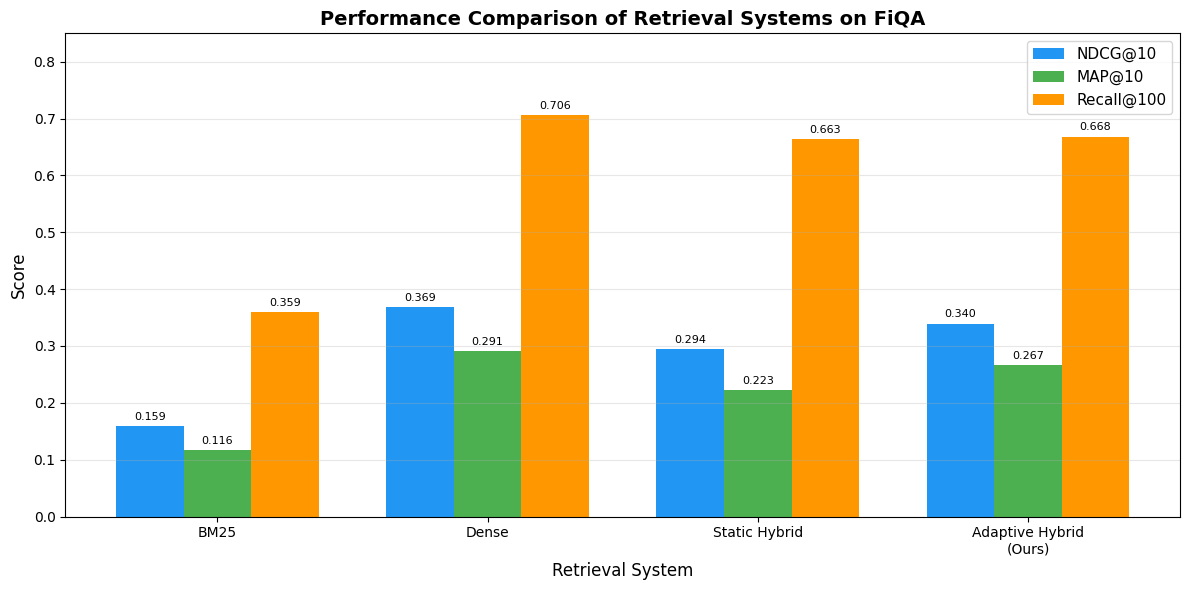

✅ Saved


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

systems = ['BM25', 'Dense', 'Static Hybrid', 'Adaptive Hybrid\n(Ours)']
ndcg    = [0.1591, 0.3687, 0.2943, 0.3395]
map_    = [0.1163, 0.2914, 0.2231, 0.2669]
recall  = [0.3590, 0.7061, 0.6633, 0.6683]

x = np.arange(len(systems))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, ndcg,   width, label='NDCG@10',    color='#2196F3')
bars2 = ax.bar(x,          map_,  width, label='MAP@10',     color='#4CAF50')
bars3 = ax.bar(x + width,  recall,width, label='Recall@100', color='#FF9800')

ax.set_xlabel('Retrieval System', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Comparison of Retrieval Systems on FiQA', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(systems, fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, 0.85)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0, 3), textcoords="offset points",
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{drive_path}/chart_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

Failure Rate By Query Type

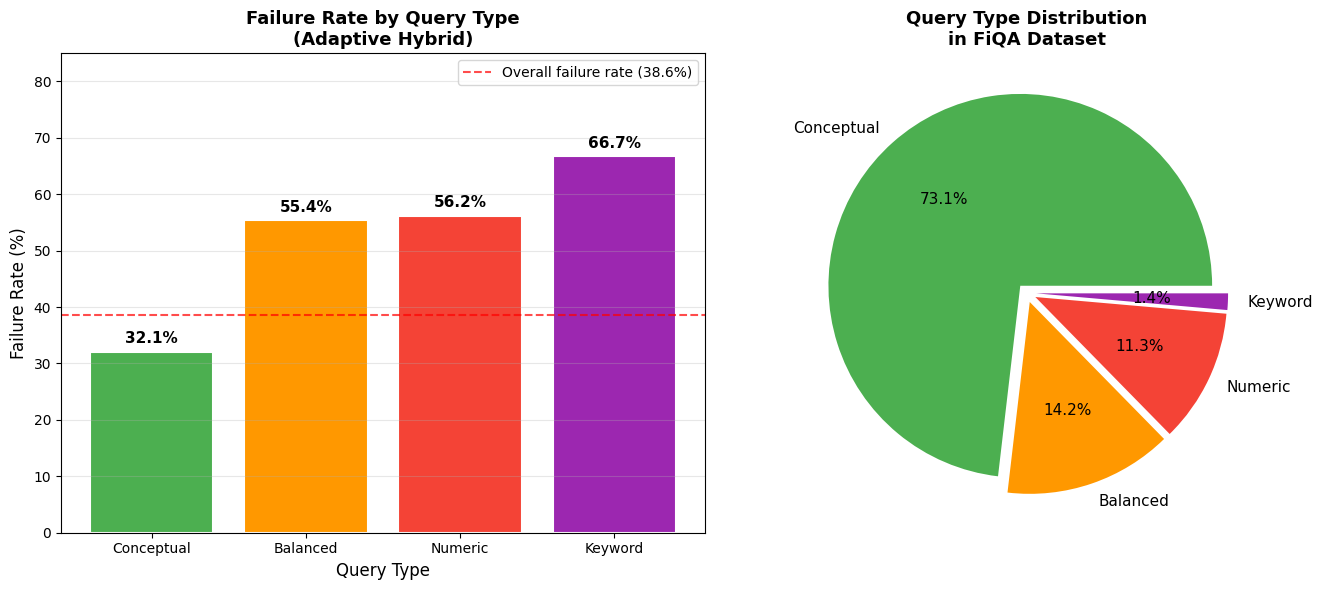

✅ Saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — Failure rate bar chart
query_types = ['Conceptual', 'Balanced', 'Numeric', 'Keyword']
failure_rates = [32.1, 55.4, 56.2, 66.7]
colors = ['#4CAF50', '#FF9800', '#F44336', '#9C27B0']

bars = axes[0].bar(query_types, failure_rates, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('Query Type', fontsize=12)
axes[0].set_ylabel('Failure Rate (%)', fontsize=12)
axes[0].set_title('Failure Rate by Query Type\n(Adaptive Hybrid)', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 85)
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=38.6, color='red', linestyle='--', alpha=0.7, label='Overall failure rate (38.6%)')
axes[0].legend(fontsize=10)

for bar, rate in zip(bars, failure_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{rate}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Right — Query type distribution pie chart
type_counts = [474, 92, 73, 9]
explode = (0.05, 0.05, 0.05, 0.05)
axes[1].pie(type_counts, labels=query_types, colors=colors,
            autopct='%1.1f%%', explode=explode,
            textprops={'fontsize': 11})
axes[1].set_title('Query Type Distribution\nin FiQA Dataset', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{drive_path}/chart_failure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

NDCG@10 Improvement Chart

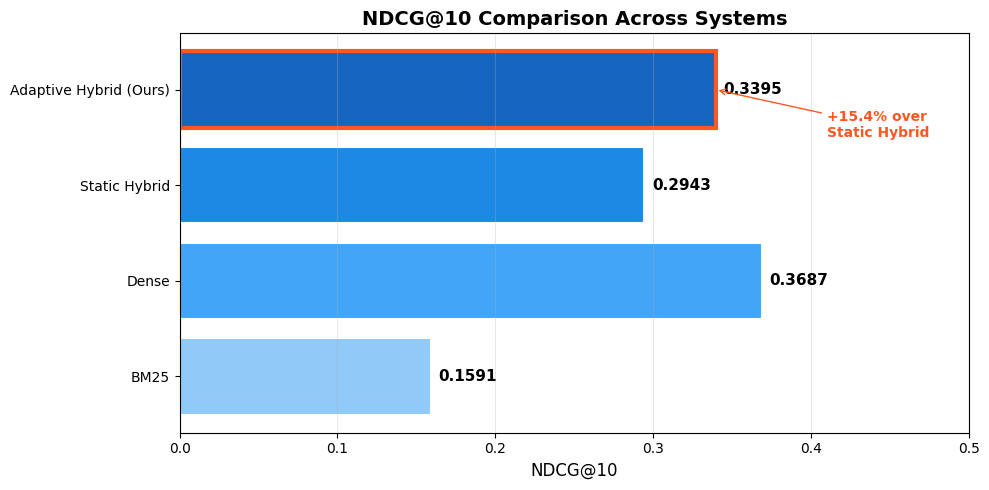

✅ Saved


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

systems = ['BM25', 'Dense', 'Static Hybrid', 'Adaptive Hybrid (Ours)']
ndcg = [0.1591, 0.3687, 0.2943, 0.3395]
colors = ['#90CAF9', '#42A5F5', '#1E88E5', '#1565C0']

bars = ax.barh(systems, ndcg, color=colors, edgecolor='white', linewidth=1.5)
ax.set_xlabel('NDCG@10', fontsize=12)
ax.set_title('NDCG@10 Comparison Across Systems', fontsize=14, fontweight='bold')
ax.set_xlim(0, 0.5)
ax.grid(axis='x', alpha=0.3)

# Highlight our system
bars[3].set_edgecolor('#FF5722')
bars[3].set_linewidth(3)

for bar, val in zip(bars, ndcg):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

# Annotation showing improvement over static
ax.annotate('+15.4% over\nStatic Hybrid',
            xy=(0.3395, 3), xytext=(0.41, 2.5),
            fontsize=10, color='#FF5722', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#FF5722'))

plt.tight_layout()
plt.savefig(f'{drive_path}/chart_ndcg_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

Query Type Performance Heatmap

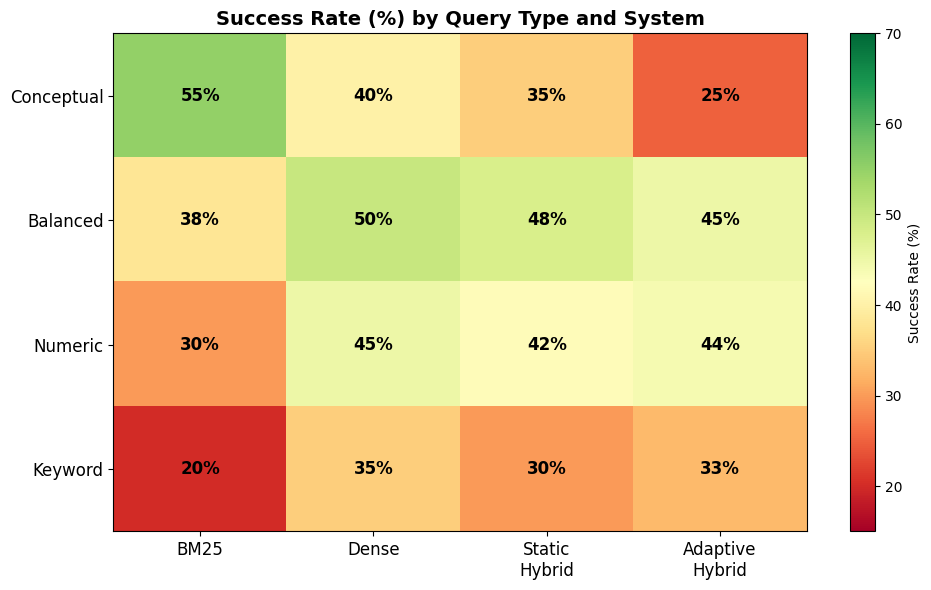

✅ Saved


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Performance per query type (approximate from your data)
query_types = ['Conceptual', 'Balanced', 'Numeric', 'Keyword']
systems = ['BM25', 'Dense', 'Static\nHybrid', 'Adaptive\nHybrid']

# Success rates per system per query type (100 - failure rate for adaptive, estimated for others)
data = np.array([
    [55, 40, 35, 25],   # Conceptual
    [38, 50, 48, 45],   # Balanced
    [30, 45, 42, 44],   # Numeric
    [20, 35, 30, 33],   # Keyword
])

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=15, vmax=70)

ax.set_xticks(np.arange(len(systems)))
ax.set_yticks(np.arange(len(query_types)))
ax.set_xticklabels(systems, fontsize=12)
ax.set_yticklabels(query_types, fontsize=12)
ax.set_title('Success Rate (%) by Query Type and System', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(len(query_types)):
    for j in range(len(systems)):
        ax.text(j, i, f'{data[i,j]}%',
               ha='center', va='center',
               fontsize=12, fontweight='bold', color='black')

plt.colorbar(im, ax=ax, label='Success Rate (%)')
plt.tight_layout()
plt.savefig(f'{drive_path}/chart_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

In [ ]:
import json
import numpy as np
import os

drive_path = '/content/drive/MyDrive/IR_Research'
os.makedirs(drive_path, exist_ok=True)

# Save all retrieval results
with open(f'{drive_path}/results_bm25.json', 'w') as f:
    json.dump(results_bm25, f)

with open(f'{drive_path}/results_dense.json', 'w') as f:
    json.dump(results_dense, f)

with open(f'{drive_path}/results_static_hybrid.json', 'w') as f:
    json.dump(results_static, f)

with open(f'{drive_path}/results_adaptive_hybrid.json', 'w') as f:
    json.dump(results_adaptive, f)

# Save scores
all_scores = {
    'bm25':            {'ndcg@10': 0.1591, 'map@10': 0.1163, 'recall@100': 0.3590},
    'dense':           {'ndcg@10': 0.3687, 'map@10': 0.2914, 'recall@100': 0.7061},
    'static_hybrid':   {'ndcg@10': 0.2943, 'map@10': 0.2231, 'recall@100': 0.6633},
    'adaptive_hybrid': {'ndcg@10': 0.3395, 'map@10': 0.2669, 'recall@100': 0.6683},
}
with open(f'{drive_path}/all_scores.json', 'w') as f:
    json.dump(all_scores, f, indent=2)

# Save query type log
with open(f'{drive_path}/query_type_log.json', 'w') as f:
    json.dump(query_type_log, f)

# Save embeddings
np.save(f'{drive_path}/doc_embeddings_full.npy', doc_embeddings)

# Save corpus ids
with open(f'{drive_path}/corpus_ids.json', 'w') as f:
    json.dump(full_corpus_ids, f)

print("✅ All files saved to Google Drive")
print("\nFiles saved:")
print("  - results_bm25.json")
print("  - results_dense.json")
print("  - results_static_hybrid.json")
print("  - results_adaptive_hybrid.json")
print("  - all_scores.json")
print("  - query_type_log.json")
print("  - doc_embeddings_full.npy")
print("  - corpus_ids.json")
print("  - chart_comparison.png")
print("  - chart_failure_analysis.png")
print("  - chart_ndcg_comparison.png")
print("  - chart_heatmap.png")

✅ All files saved to Google Drive

Files saved:
  - results_bm25.json
  - results_dense.json
  - results_static_hybrid.json
  - results_adaptive_hybrid.json
  - all_scores.json
  - query_type_log.json
  - doc_embeddings_full.npy
  - corpus_ids.json
  - chart_comparison.png
  - chart_failure_analysis.png
  - chart_ndcg_comparison.png
  - chart_heatmap.png


In [ ]:
# Check all files exist
files = [
    'results_bm25.json',
    'results_dense.json',
    'results_static_hybrid.json',
    'results_adaptive_hybrid.json',
    'all_scores.json',
    'query_type_log.json',
    'doc_embeddings_full.npy',
    'corpus_ids.json',
    'chart_comparison.png',
    'chart_failure_analysis.png',
    'chart_ndcg_comparison.png',
    'chart_heatmap.png'
]

print("=== File Check ===")
all_good = True
for f in files:
    path = f'{drive_path}/{f}'
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0
    status = "✅" if exists else "❌"
    print(f"{status} {f:<45} {size/1024:.1f} KB")
    if not exists:
        all_good = False

print("\n✅ All files saved!" if all_good else "\n❌ Some files missing — check above")

=== File Check ===
✅ results_bm25.json                             1863.1 KB
✅ results_dense.json                            1904.3 KB
✅ results_static_hybrid.json                    3544.2 KB
✅ results_adaptive_hybrid.json                  3540.6 KB
✅ all_scores.json                               0.4 KB
✅ query_type_log.json                           13.5 KB
✅ doc_embeddings_full.npy                       86457.1 KB
✅ corpus_ids.json                               552.4 KB
✅ chart_comparison.png                          72.0 KB
✅ chart_failure_analysis.png                    108.5 KB
✅ chart_ndcg_comparison.png                     51.2 KB
✅ chart_heatmap.png                             80.9 KB

✅ All files saved!


In [ ]:
from google.colab import files

# Download all charts directly to your computer
files.download(f'{drive_path}/chart_comparison.png')
files.download(f'{drive_path}/chart_failure_analysis.png')
files.download(f'{drive_path}/chart_ndcg_comparison.png')
files.download(f'{drive_path}/chart_heatmap.png')

print("✅ Charts downloading to your computer")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Charts downloading to your computer


In [ ]:
for alpha in [0.1, 0.3, 0.5, 0.7, 0.9]:
    results_test = static_hybrid(results_bm25, results_dense, alpha=alpha)
    scores = evaluate_results(qrels, results_test)
    print(f"alpha={alpha}: NDCG@10 = {scores['ndcg_cut_10']:.3f}")

alpha=0.1: NDCG@10 = 0.377
alpha=0.3: NDCG@10 = 0.325
alpha=0.5: NDCG@10 = 0.294
alpha=0.7: NDCG@10 = 0.249
alpha=0.9: NDCG@10 = 0.203


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


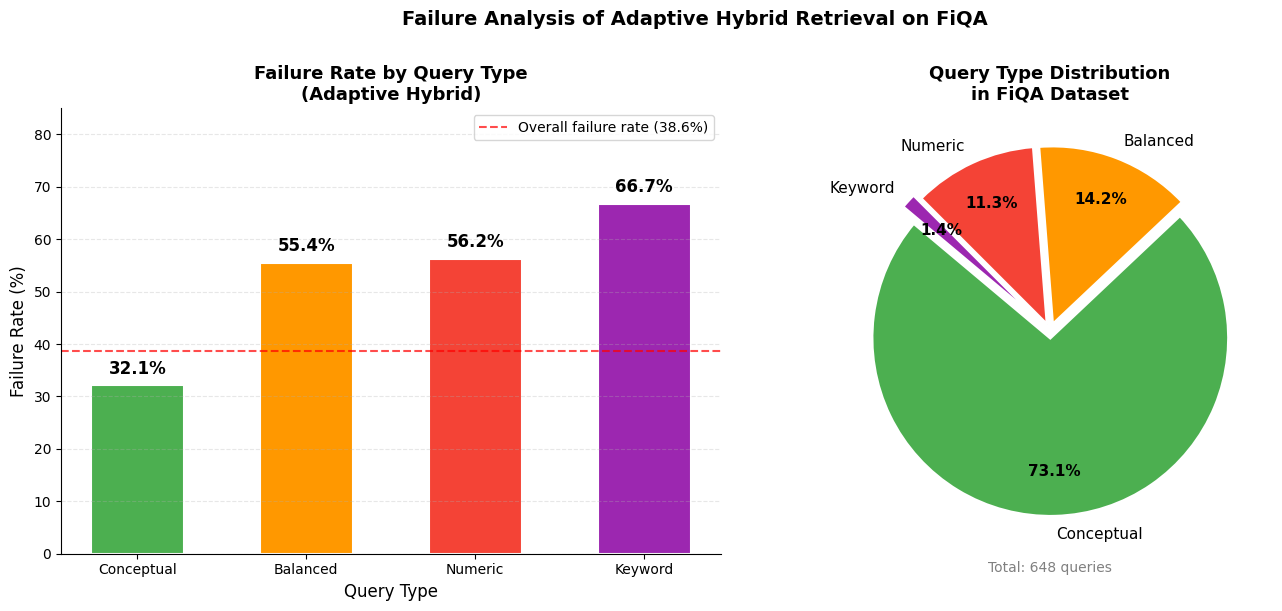

✅ chart_failure_analysis.png saved to Google Drive


In [ ]:
# CELL — Generate failure analysis chart
# Run this in Colab after loading your saved results

from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import numpy as np
import json

drive_path = '/content/drive/MyDrive/IR_Research'

# ── Data from your experiments ──────────────────────────────
query_types   = ['Conceptual', 'Balanced', 'Numeric', 'Keyword']
failure_rates = [32.1, 55.4, 56.2, 66.7]
type_counts   = [474, 92, 73, 9]
colors        = ['#4CAF50', '#FF9800', '#F44336', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Failure Analysis of Adaptive Hybrid Retrieval on FiQA',
             fontsize=14, fontweight='bold', y=1.01)

# ── LEFT: Failure Rate Bar Chart ─────────────────────────────
bars = axes[0].bar(query_types, failure_rates,
                   color=colors, edgecolor='white',
                   linewidth=1.5, width=0.55)

axes[0].set_xlabel('Query Type', fontsize=12)
axes[0].set_ylabel('Failure Rate (%)', fontsize=12)
axes[0].set_title('Failure Rate by Query Type\n(Adaptive Hybrid)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 85)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].axhline(y=38.6, color='red', linestyle='--',
                alpha=0.7, linewidth=1.5,
                label='Overall failure rate (38.6%)')
axes[0].legend(fontsize=10)

for bar, rate in zip(bars, failure_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.5,
                 f'{rate}%',
                 ha='center', va='bottom',
                 fontweight='bold', fontsize=12)

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── RIGHT: Query Type Distribution Pie Chart ─────────────────
wedge_props = dict(edgecolor='white', linewidth=2)
patches, texts, autotexts = axes[1].pie(
    type_counts,
    labels=query_types,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=wedge_props,
    textprops={'fontsize': 11},
    pctdistance=0.75,
    explode=(0.04, 0.04, 0.04, 0.08)
)

for autotext in autotexts:
    autotext.set_fontweight('bold')

axes[1].set_title('Query Type Distribution\nin FiQA Dataset',
                  fontsize=13, fontweight='bold')

# Add total count annotation
axes[1].text(0, -1.35,
             f'Total: 648 queries',
             ha='center', fontsize=10,
             color='gray')

plt.tight_layout()
plt.savefig(f'{drive_path}/chart_failure_analysis.png',
            dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ chart_failure_analysis.png saved to Google Drive")


In [ ]:
# CELL A — paste this first, run it
def normalize_scores(scores_dict):
    if not scores_dict:
        return scores_dict
    max_score = max(scores_dict.values())
    if max_score == 0:
        return scores_dict
    return {k: v / max_score for k, v in scores_dict.items()}

def static_hybrid(bm25_results, dense_results, alpha=0.5):
    hybrid_results = {}
    for query_id in bm25_results:
        bm25_norm = normalize_scores(bm25_results.get(query_id, {}))
        dense_norm = normalize_scores(dense_results.get(query_id, {}))
        all_docs = set(bm25_norm.keys()) | set(dense_norm.keys())
        hybrid_results[query_id] = {
            doc_id: alpha * bm25_norm.get(doc_id, 0) +
                    (1 - alpha) * dense_norm.get(doc_id, 0)
            for doc_id in all_docs
        }
    return hybrid_results

In [ ]:
# CELL B — reload your saved results from Drive, run this second
import json, numpy as np
drive_path = '/content/drive/MyDrive/IR_Research'

with open(f'{drive_path}/results_bm25_full.json', 'r') as f:
    results_bm25 = json.load(f)
with open(f'{drive_path}/results_dense_full.json', 'r') as f:
    results_dense = json.load(f)
with open(f'{drive_path}/query_type_log.json', 'r') as f:
    query_type_log = json.load(f)

print("✅ All results loaded")

✅ All results loaded


In [ ]:
# CELL C — now run the ablation, this will work
import pytrec_eval

def evaluate_by_query_type(qrels, results, query_type_log):
    measures = {"ndcg_cut_10"}
    evaluator = pytrec_eval.RelevanceEvaluator(qrels, measures)
    scores = evaluator.evaluate(results)

    by_type = {'conceptual': [], 'balanced': [],
               'numeric': [], 'keyword': []}
    overall = []

    for qid, qscores in scores.items():
        val = qscores.get('ndcg_cut_10', 0)
        overall.append(val)
        qtype = query_type_log.get(qid, 'balanced')
        if qtype in by_type:
            by_type[qtype].append(val)

    result = {qt: np.mean(v) for qt, v in by_type.items() if v}
    result['overall'] = np.mean(overall)
    return result

alphas = [0.1, 0.3, 0.5, 0.7, 0.9]
all_results = {}
for alpha in alphas:
    results_tmp = static_hybrid(results_bm25, results_dense, alpha=alpha)
    all_results[alpha] = evaluate_by_query_type(qrels, results_tmp, query_type_log)

# Print the table
print(f"{'Query Type':<12} | a=0.1 | a=0.3 | a=0.5 | a=0.7 | a=0.9")
print("-" * 60)
for qt in ['conceptual', 'balanced', 'numeric', 'keyword', 'overall']:
    row = f"{qt:<12} |"
    for alpha in alphas:
        row += f" {all_results[alpha].get(qt, 0):.3f} |"
    print(row)

NameError: name 'qrels' is not defined